<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2/01_explore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: The Data

This notebook introduces the toy car panel and the raw material used in the rest of the
labs: product descriptions, product images, and a short time series of prices and sales
ranks. At the end we run a naive regression of quantity on price. It returns an answer
that cannot be right, which sets up everything that follows.

Labs 3, 4 and 5 need the embeddings produced by Lab 2. This notebook does not, so it runs
on CPU.

## Background

The data cover toy products on Amazon.com between March 2023 and January 2024, compiled by
the data aggregator Keepa.com. For each product we observe the sales rank and the buy box
price over time, along with a product description, an image, and a few tabular attributes.
The full data set has $N = 7{,}226$ products. These labs use a subsample small enough to
fine-tune on a free Colab GPU.

## Notation and variable definitions

Let $i$ index products and $t$ index four-week periods.

**Quantity signal.** Amazon does not publish unit sales, so we use the sales rank as a
proxy. A higher rank number means fewer units sold, so we invert it:
$$Q_{it} = \log\bigl(1/\text{Time-Averaged Sales Rank of } i \text{ in period } t\bigr).$$
A higher $Q_{it}$ means the product sells more relative to others in the category.

**Price signal.** The buy box price is the price shown to a buyer ready to purchase:
$$P_{it} = \log\bigl(\text{Time-Averaged Price of } i \text{ in period } t\bigr).$$

Both signals are in logs, so a regression coefficient of $Q$ on $P$ reads as an
elasticity. We also use the temporal changes $\Delta Q_{it} = Q_{it} - Q_{i,t-1}$ and
$\Delta P_{it} = P_{it} - P_{i,t-1}$.

**Remark (Pareto interpretation).** Rank is not quantity. Under a Pareto distribution with
shape $\vartheta$ for units sold, the price sensitivity of actual demand is approximately
$1/\vartheta$ times the rank elasticity. He and Hollenbeck (2020) estimate
$\hat{\vartheta} \approx 0.5$ for toys on Amazon, so multiplying a rank elasticity by
about 2 gives an approximate demand elasticity. We use this conversion throughout.

## Setup

In [1]:
import io
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from PIL import Image

palette = sns.color_palette("colorblind")
pd.set_option("display.width", 120)

## Building the subsample

The reproduction repository stores the data in two pieces: a panel of prices, sales ranks,
descriptions and tabular attributes (about 42 MB), and product images split across sixteen
parquet part-files of roughly 90 MB each.

A part-file cannot be queried for a single product's image, so the three files listed in
the next cell determine which products are available to us. They cover 2,000 products, of
which 911 have a complete 14-period panel. We draw 800 of those.

> The constants in the next cell must match Lab 2. Both notebooks rebuild the subsample
> from scratch, and the draw is deterministic, so the same constants give the same
> products.

In [2]:
# ---------------------------------------------------------------------------
# Configuration. Keep this cell identical in Labs 1 and 2.
# ---------------------------------------------------------------------------
BASE = ("https://raw.githubusercontent.com/JanTeichertKluge/"
        "demand-analysis-repro/main/main/data")

N_PRODUCTS = 800   # products in the subsample
N_FINETUNE = 300   # of those, the ones Lab 2 trains on (the paper's I_1)
SEED = 42

panel_files = [
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/train-00000-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/train-00001-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/validation-00000-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/validation-00001-of-00002.parquet",
]

# An image file holds a fixed set of products and cannot be queried for a single
# product, so these three files determine the pool we draw from: 2,000 images, of
# which 911 belong to a product with a complete panel. Add more parts from the
# same folder for a larger sample.
image_files = [
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00000-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00001-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00002-of-00004-part000.parquet",
]

os.makedirs("data_cache", exist_ok=True)
for remote in panel_files + image_files:
    local = "data_cache/" + remote.split("/")[-1]
    if not os.path.exists(local):
        print("downloading", local, flush=True)
        urllib.request.urlretrieve(f"{BASE}/{remote}", local)

print("data ready (~320 MB, cached for this session)")

downloading data_cache/train-00000-of-00002.parquet
downloading data_cache/train-00001-of-00002.parquet
downloading data_cache/validation-00000-of-00002.parquet
downloading data_cache/validation-00001-of-00002.parquet
downloading data_cache/train-00000-of-00004-part000.parquet
downloading data_cache/train-00001-of-00004-part000.parquet
downloading data_cache/train-00002-of-00004-part000.parquet
data ready (~320 MB, cached for this session)


In [3]:
columns = ["ASIN", "window", "date", "SALES_RANK", "BUYBOX_PRICE", "text",
           "RATING", "REVIEW_COUNT", "subcat_aggregated",
           "New Offer Count: Current",
           "Count of retrieved live offers: New, FBA",
           "Count of retrieved live offers: New, FBM",
           "Lightning Deals: Upcoming Deal", "Buy Box: Is FBA"]

panel = pd.concat([pd.read_parquet("data_cache/" + f.split("/")[-1], columns=columns)
                   for f in panel_files], ignore_index=True)

# Keep the 28-day time averages, then every fourth week: 14 four-week periods
# from 2023-01-30 to 2024-01-29. SALES_RANK is already log(1 / sales rank) and
# BUYBOX_PRICE already log(price), so they are the paper's Q_it and P_it.
panel = panel[panel["window"] == 28].drop(columns="window")
dates = np.sort(panel["date"].unique())
panel["date_t"] = panel["date"].map({d: i for i, d in enumerate(dates)})
panel = panel[(panel["date_t"] <= 54) & (panel["date_t"] % 4 == 0)].dropna()
panel["period"] = panel["date_t"] // 4
panel = panel.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"})

# Eligible products: we have an image, and they are observed in all 14 periods.
have_image = set(pd.concat(
    [pd.read_parquet("data_cache/" + f.split("/")[-1], columns=["ASIN"])
     for f in image_files], ignore_index=True)["ASIN"])
n_periods = panel.groupby("ASIN")["period"].nunique()
candidates = np.array(sorted(set(n_periods[n_periods == 14].index) & have_image))

# Deterministic draw, then a split by product. Labs 4 and 5 estimate only on
# the "estimation" products, so the embeddings they use were fitted on different
# products. The paper's Addendum A relies on that independence.
rng = np.random.default_rng(SEED)
chosen = np.sort(rng.choice(candidates, size=N_PRODUCTS, replace=False))
finetune = set(chosen[rng.permutation(N_PRODUCTS)[:N_FINETUNE]])

df = panel[panel["ASIN"].isin(set(chosen))].sort_values(["ASIN", "period"])
df = df.reset_index(drop=True)
df["split"] = np.where(df["ASIN"].isin(finetune), "finetune", "estimation")

# Lagged state and first differences, within product
grouped = df.groupby("ASIN")
df["Q_t-1"] = grouped["Q_t"].shift(1)
df["P_bb_t-1"] = grouped["P_bb_t"].shift(1)
df["RATING_t-1"] = grouped["RATING"].shift(1)
df["REVIEW_COUNT_t-1"] = grouped["REVIEW_COUNT"].shift(1)
df["Delta_Q_t"] = df["Q_t"] - df["Q_t-1"]
df["Delta_P_bb_t"] = df["P_bb_t"] - df["P_bb_t-1"]

print(f"{len(candidates):,} products qualify; using {N_PRODUCTS}")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size")))

911 products qualify; using 800
            products  rows
split                     
estimation       500  7000
finetune         300  4200


In [4]:
df[["ASIN", "date", "period", "split", "Q_t", "P_bb_t"]].head()

,ASIN,date,period,split,Q_t,P_bb_t
0,194749497X,2023-01-30,0,estimation,-10.625625,3.739793
1,194749497X,2023-02-27,1,estimation,-10.701107,3.947769
2,194749497X,2023-03-27,2,estimation,-11.035231,3.999164
3,194749497X,2023-04-24,3,estimation,-11.085148,3.998201
4,194749497X,2023-05-22,4,estimation,-11.132251,3.998201


### The variables

| Variable | Description |
|---|---|
| `Q_t` | $\log(1/\text{sales rank})$, the quantity signal |
| `P_bb_t` | $\log(\text{buy-box price})$, excluding shipping and handling |
| `REVIEW_COUNT` | Number of reviews |
| `RATING` | Average customer rating |
| `Lightning Deals: Upcoming Deal` | 1 if the product is promoted via a lightning deal |
| `Buy Box: Is FBA` | 1 if delivery is fulfilled by Amazon |
| `text` | Unstructured description: title, manufacturer, brand, model, colour, size |
| `subcat_aggregated` | Product subcategory |
| `ASIN` | Unique product ID |

The description, the image, the ID and the subcategory are fixed for a product. Every
other variable can move over time. The distinction returns in Lab 3, where it explains why
the embeddings act as effect modifiers rather than confounders.

## What a product looks like

A product carries much more information than the tabular columns record. The description
gives brand, scale, material and theme; the image shows shape, colour and styling. Neither
can enter a regression until a model turns it into numbers, which is the job of Lab 2.

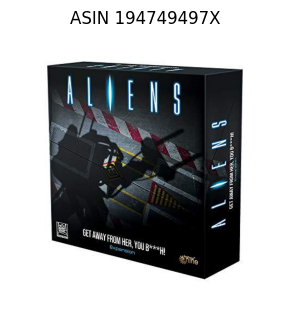

subcategory: Residual
rating: 4.7   reviews: 1501

description (1374 characters):

Gale Force Nine Table Top Game, Black, 8 x 26 x 26 Centimeters | Board Games, Vehicles | The Aliens have taken Newt and some of our own Marines. We don’t leave anyone behind. We do whatever we need to do to retrieve them and get back to the ship Aliens: Get Away From Her, You Bh! expands the Campaign to five expanded Missions and adds five new Bug Hunt Missions, two of which feature the Alien Queen. It also allows one player to play as the Alien Hive, giving you another way to play Campaign and Bug Hunt Missions. This expansion is not a stand alone game. You will need copy of the Aliens: Another Glorious Day in the Corps to use this expansion. | Gale Force Nine - Aliens: Another Glorious Day in the Corps: Get Away From Her, You BxXxh! Expansion - Board Game | Lead a fireteam of Marines through the colonists base at Hadley’s Hope, searching for survivors and tackling the Xenomorph threat, ...


In [5]:
example_asin = df["ASIN"].iloc[0]
example = df[df["ASIN"] == example_asin].iloc[0]

image = None
for f in image_files:
    table = pd.read_parquet("data_cache/" + f.split("/")[-1])
    hit = table[table["ASIN"] == example_asin]
    if len(hit):
        image = Image.open(io.BytesIO(hit["image"].iloc[0]["bytes"])).convert("RGB")
        break

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.imshow(image)
ax.axis("off")
ax.set_title(f"ASIN {example_asin}")
plt.show()

print(f"subcategory: {example['subcat_aggregated']}")
print(f"rating: {example['RATING']:.1f}   reviews: {example['REVIEW_COUNT']:.0f}")
print()
print(f"description ({len(example['text'])} characters):")
print()
print(example["text"][:900] + " ...")

## Prices and sales ranks over time

Sales ranks move from week to week. Prices tend to sit at one value for weeks and then
jump. The asymmetry matters for the identification argument in Lab 4: if prices rarely
move, they are unlikely to be responding to short run demand shocks.

The solid line is the weekly series and the dashed line is the 28-day average used in the
labs.

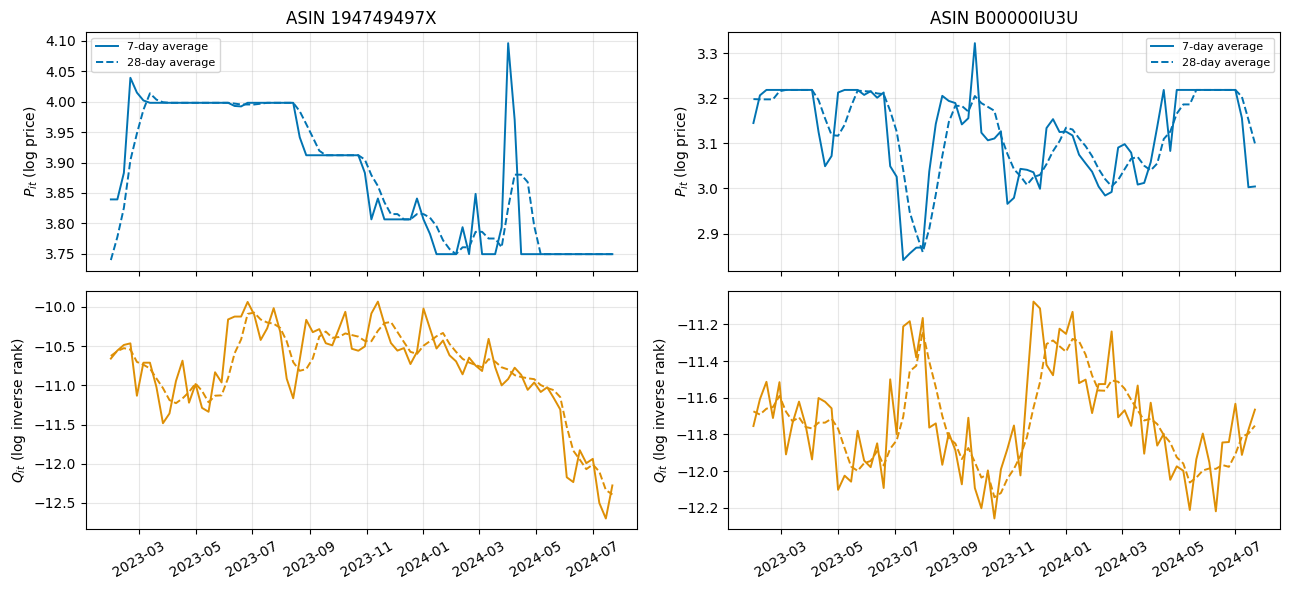

In [6]:
examples = df["ASIN"].drop_duplicates().iloc[:2].tolist()

weekly = pd.concat([pd.read_parquet("data_cache/" + f.split("/")[-1],
                                    columns=["ASIN", "window", "date",
                                             "SALES_RANK", "BUYBOX_PRICE"])
                    for f in panel_files], ignore_index=True)
weekly = weekly[weekly["ASIN"].isin(examples)].copy()
weekly["date"] = pd.to_datetime(weekly["date"])
weekly = weekly.sort_values(["ASIN", "window", "date"])

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for j, asin in enumerate(examples):
    for i, (col, label) in enumerate([("BUYBOX_PRICE", "$P_{it}$ (log price)"),
                                      ("SALES_RANK", "$Q_{it}$ (log inverse rank)")]):
        ax = axes[i, j]
        for w, style in [(7, "-"), (28, "--")]:
            s = weekly[(weekly["ASIN"] == asin) & (weekly["window"] == w)]
            ax.plot(s["date"], s[col], style, color=palette[i], lw=1.4,
                    label=f"{w}-day average")
        ax.set_ylabel(label)
        ax.grid(alpha=0.3)
        if i == 0:
            ax.set_title(f"ASIN {asin}")
            ax.legend(fontsize=8)
for ax in axes[1]:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Descriptive statistics

In [7]:
df[["Q_t", "P_bb_t", "RATING", "REVIEW_COUNT"]].describe().round(3)

,Q_t,P_bb_t,RATING,REVIEW_COUNT
count,11200.000,11200.000,11200.000,11200.000
mean,-10.457,3.071,4.531,1853.052
std,1.538,0.551,0.267,5679.075
min,-14.230,1.590,1.000,-1.000
25%,-11.499,2.706,4.400,148.848
50%,-10.808,3.091,4.600,511.982
75%,-9.947,3.376,4.700,1563.187
max,-2.950,5.564,5.000,100314.357


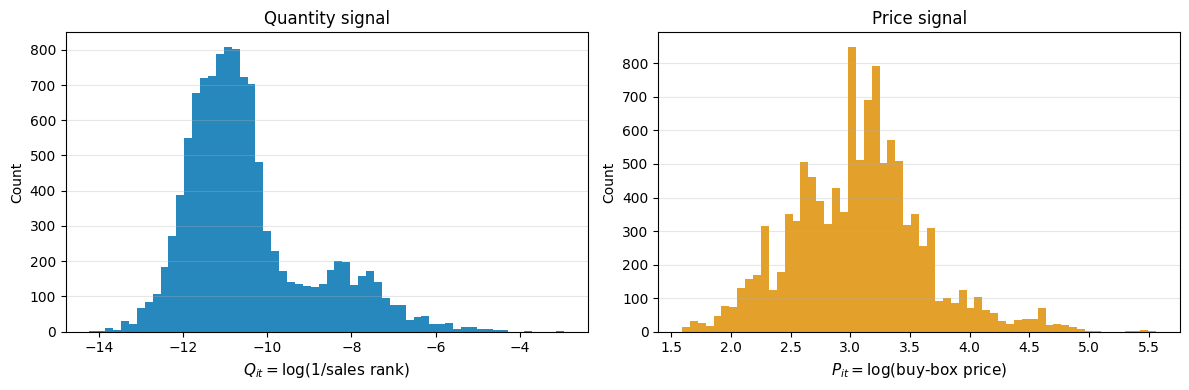

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Q_t"], bins=60, color=palette[0], alpha=0.85, edgecolor="none")
axes[0].set_xlabel("$Q_{it} = \\log(1/\\mathrm{sales\\ rank})$", fontsize=11)
axes[0].set_title("Quantity signal")

axes[1].hist(df["P_bb_t"], bins=60, color=palette[1], alpha=0.85, edgecolor="none")
axes[1].set_xlabel("$P_{it} = \\log(\\mathrm{buy\\text{-}box\\ price})$", fontsize=11)
axes[1].set_title("Price signal")

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

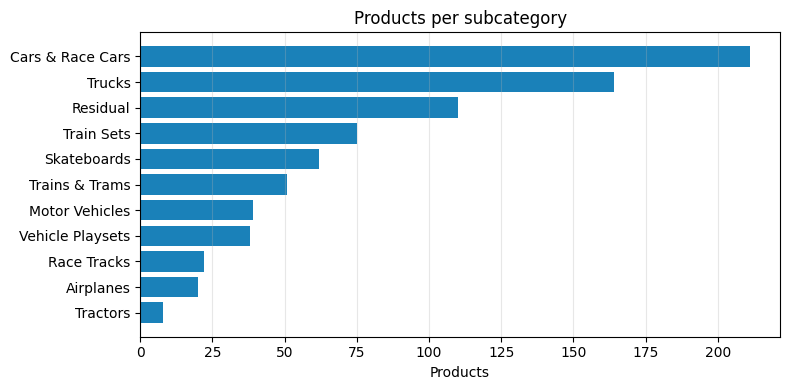

In [9]:
counts = df.groupby("subcat_aggregated")["ASIN"].nunique().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(counts.index, counts.values, color=palette[0], alpha=0.9)
ax.set_xlabel("Products")
ax.set_title("Products per subcategory")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Levels move, changes barely do

Compare the spread of the levels above with the spread of the period-to-period changes
below. The price signal has a standard deviation of about 0.55 in levels and about 0.09 in
changes. Prices are sticky.

Product features can explain a good deal about why one product is more expensive than
another, and very little about why a given product's price moved this month. Lab 3
measures the difference and Labs 4 and 5 build on it.

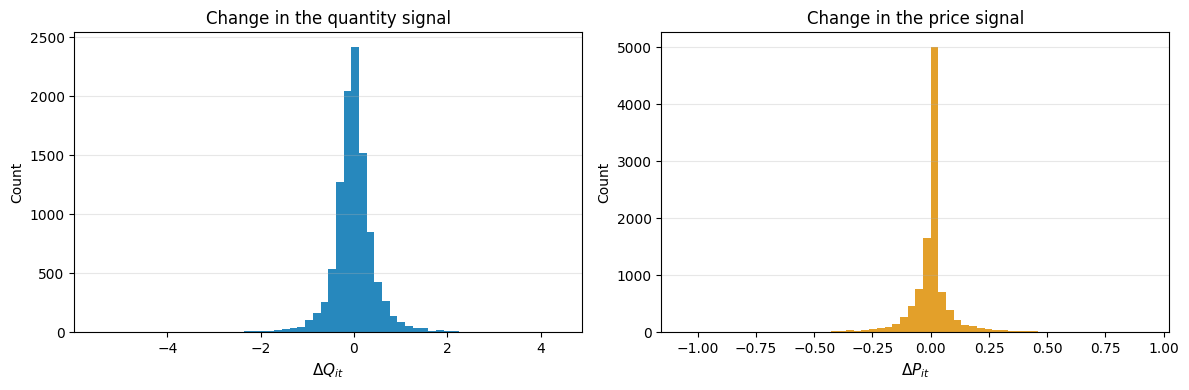

Q_t             1.534
P_bb_t          0.551
Delta_Q_t       0.459
Delta_P_bb_t    0.092

share of periods with an exactly unchanged price: 34.5%


In [10]:
chg = df.dropna(subset=["Delta_Q_t", "Delta_P_bb_t"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(chg["Delta_Q_t"], bins=60, color=palette[0], alpha=0.85, edgecolor="none")
axes[0].set_xlabel("$\\Delta Q_{it}$", fontsize=11)
axes[0].set_title("Change in the quantity signal")

axes[1].hist(chg["Delta_P_bb_t"], bins=60, color=palette[1], alpha=0.85, edgecolor="none")
axes[1].set_xlabel("$\\Delta P_{it}$", fontsize=11)
axes[1].set_title("Change in the price signal")

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(chg[["Q_t", "P_bb_t", "Delta_Q_t", "Delta_P_bb_t"]].std().round(3).to_string())
print(f"\nshare of periods with an exactly unchanged price: "
      f"{(chg['Delta_P_bb_t'].abs() < 1e-8).mean():.1%}")

## A first, naive elasticity

The obvious regression is the quantity signal on the price signal,
$$L[Q_{it} \mid P_{it}, X_{it}] = \delta P_{it} + g_t(X_{it}),$$
first without controls and then with the tabular ones.

In [11]:
naive = sm.OLS(df["Q_t"], sm.add_constant(df["P_bb_t"])).fit(
    cov_type="cluster", cov_kwds={"groups": df["ASIN"]})
print(naive.summary().tables[1])
print(f"\nimplied demand elasticity (x2): {2 * naive.params['P_bb_t']:.3f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.0891      0.289    -34.896      0.000     -10.656      -9.522
P_bb_t        -0.1198      0.091     -1.312      0.190      -0.299       0.059

implied demand elasticity (x2): -0.240


In [12]:
X = sm.add_constant(df[["P_bb_t", "RATING", "REVIEW_COUNT"]])
X = pd.concat(
    [X, pd.get_dummies(df["subcat_aggregated"], prefix="sub", drop_first=True).astype(int)],
    axis=1)

controlled = sm.OLS(df["Q_t"], X).fit(
    cov_type="cluster", cov_kwds={"groups": df["ASIN"]})
print(controlled.summary().tables[1].as_text()[:1400])
print(f"\ndelta = {controlled.params['P_bb_t']:.3f}   "
      f"implied demand elasticity (x2): {2 * controlled.params['P_bb_t']:.3f}")

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -11.6406      0.758    -15.365      0.000     -13.125     -10.156
P_bb_t                  -0.2228      0.084     -2.654      0.008      -0.387      -0.058
RATING                   0.5068      0.150      3.379      0.001       0.213       0.801
REVIEW_COUNT             0.0001   2.23e-05      4.823      0.000    6.38e-05       0.000
sub_Cars & Race Cars    -0.9120      0.419     -2.175      0.030      -1.734      -0.090
sub_Motor Vehicles      -0.2708      0.462     -0.586      0.558      -1.177       0.635
sub_Race Tracks          0.1167      0.489      0.239      0.811      -0.841       1.075
sub_Residual            -0.8312      0.431     -1.930      0.054      -1.675       0.013
sub_Skateboards         -0.9810      0.424     -2.312      0.021      -1.813      -0.149
sub_Tractors         

## Why this answer cannot be right

Both regressions put $\delta$ between about $-0.3$ and $-0.1$. After the Pareto conversion
that implies a 1% price rise costs a few tenths of a percent of units sold, which would
let a seller raise prices almost freely. For toy cars on a marketplace where a close
substitute is one click away, this is not credible.

The estimator is fine. The problem is omitted variables. Popular, high quality, highly
visible products sell more and also sustain higher prices. That common driver biases
$\hat\delta$ towards zero. Correcting it requires measures of product quality and
visibility, and neither is a column in this table. They are latent, and the closest thing
we have to a measurement is the description and the image.

The remaining labs follow from this:

* **Lab 2** turns text and images into embeddings, fine-tuned to predict price and
  quantity.
* **Lab 3** measures how much those embeddings help in predicting $Q$, $P$, $\Delta Q$ and
  $\Delta P$.
* **Lab 4** estimates the average price elasticity by double machine learning, using
  lagged quantity and price as the state variables that carry visibility and quality.
* **Lab 5** allows the elasticity to vary across products.